<a href="https://colab.research.google.com/github/akshaykumar1828/crypto-sentiment-analysis/blob/main/Crypto_Sentiment_vs_Trader_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_history = pd.read_csv("historical_data.csv")
df_sentiment = pd.read_csv("fear_greed_index.csv")

In [3]:
print(df_history.shape)
df_history.head()

(211224, 16)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [4]:
print(df_sentiment.shape)
df_sentiment.head()

(2644, 4)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
df_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [7]:
df_sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [8]:
df_history['Account'].nunique()

32

In [9]:
#number of trades by each trader
df_history['Account'].value_counts()

,count
Account,
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,40184
0xbaaaf6571ab7d571043ff1e313a9609a10637864,21192
0xa0feb3725a9335f49874d7cd8eaad6be45b27416,15605
0x8477e447846c758f5a675856001ea72298fd9cb5,14998
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,14733
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311
0x513b8629fe877bb581bf244e326a047b249c4ff1,12236
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,9893
0x47add9a56df66b524d5e2c1993a43cde53b6ed85,8519


## Combining two Datasets based on date column

In [11]:
df_history['Timestamp IST'] = pd.to_datetime(df_history['Timestamp IST'],dayfirst=True)
df_sentiment['date'] = pd.to_datetime(df_sentiment['date'])

In [13]:
df_history['date'] = df_history['Timestamp IST'].dt.date
df_sentiment['date'] = df_sentiment['date'].dt.date

In [15]:
df = pd.merge(df_history, df_sentiment, on='date', how='left')

In [17]:
print(df_history['date'].min(), df_history['date'].max())
print(df_sentiment['date'].min(), df_sentiment['date'].max())

2023-05-01 2025-05-01
2018-02-01 2025-05-02


### What are the assets available?

In [29]:
df['Coin'].unique()

array(['@107', 'AAVE', 'DYDX', 'AIXBT', 'GMX', 'EIGEN', 'HYPE', 'SOL',
       'SUI', 'DOGE', 'ETH', 'kPEPE', 'TRUMP', 'ONDO', 'ENA', 'LINK',
       'XRP', 'S', 'BNB', 'BERA', 'WIF', 'LAYER', 'MKR', 'KAITO', 'IP',
       'JUP', 'USUAL', 'ADA', 'BTC', 'PURR/USDC', 'ZRO', '@7', '@19',
       '@21', '@44', '@48', '@11', '@15', '@46', '@61', '@28', '@45',
       '@9', '@41', '@38', 'kSHIB', 'GRASS', 'TAO', 'AVAX', '@2', '@6',
       '@8', '@10', '@12', '@16', '@17', '@35', '@26', '@24', '@32',
       '@29', '@31', '@33', '@34', '@36', '@37', '@47', '@53', '@74',
       'RUNE', 'CANTO', 'NTRN', 'BLUR', 'ZETA', 'MINA', 'MANTA', 'RNDR',
       'WLD', 'kBONK', 'ALT', 'INJ', 'STG', 'ZEN', 'MAVIA', 'PIXEL',
       'ILV', 'FET', 'STRK', 'CAKE', 'STX', 'ACE', 'PENDLE', 'AR', 'XAI',
       'APE', 'MEME', 'NEAR', 'SEI', 'FTM', 'MYRO', 'BIGTIME', 'IMX',
       'BADGER', 'POLYX', 'OP', 'TNSR', 'MAV', 'TIA', 'MERL', 'TON',
       'PURR', 'ME', 'CRV', 'BRETT', 'CHILLGUY', 'MOODENG', 'VIRTUAL',
       'CO

In [28]:
df.groupby('Coin')['Account'].nunique()

,Account
Coin,
@1,2
@10,2
@100,2
@103,3
@107,27
...,...
kBONK,4
kFLOKI,2
kNEIRO,1


In [20]:
coin_traders = df.groupby('Coin')['Account'].nunique().reset_index()
coin_traders.columns = ['Coin', 'Number of Traders']

In [22]:
coin_traders.describe()

,Number of Traders
count,246.000000
mean,3.256098
std,3.596407
min,1.000000
25%,1.000000
50%,2.000000
75%,4.000000
max,27.000000


In [23]:
low_coins = coin_traders[coin_traders['Number of Traders'] < 5]['Coin']

df['Coin_Grouped'] = df['Coin'].apply(
    lambda x: 'Others' if x in low_coins.values else x
)

In [24]:
coin_grouped = df.groupby('Coin_Grouped')['Account'].nunique().reset_index()
coin_grouped.columns = ['Coin', 'Number of Traders']

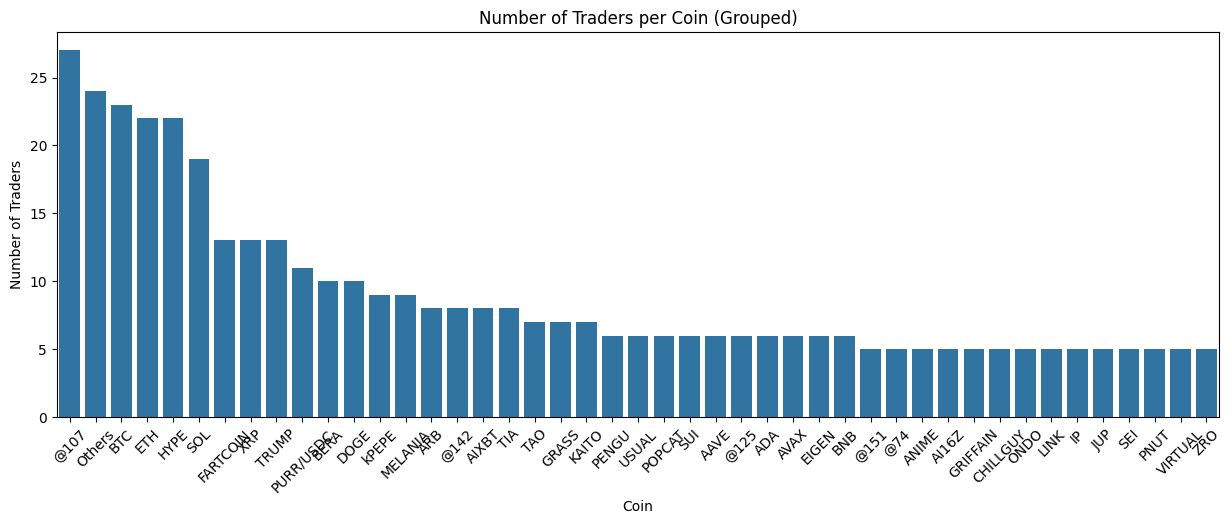

In [26]:
plt.figure(figsize=(15,5))

sns.barplot(
    data=coin_grouped.sort_values(by='Number of Traders', ascending=False),
    x='Coin',
    y='Number of Traders'
)

plt.title("Number of Traders per Coin (Grouped)")
plt.xlabel("Coin")
plt.ylabel("Number of Traders")

plt.xticks(rotation=45)
plt.show()

### Overall trade analysis per year

In [31]:
df_sentiment['date'] = pd.to_datetime(df_sentiment['date'])

In [32]:
df_sentiment['year'] = df_sentiment['date'].dt.year
df_sentiment['day_of_year'] = df_sentiment['date'].dt.dayofyear

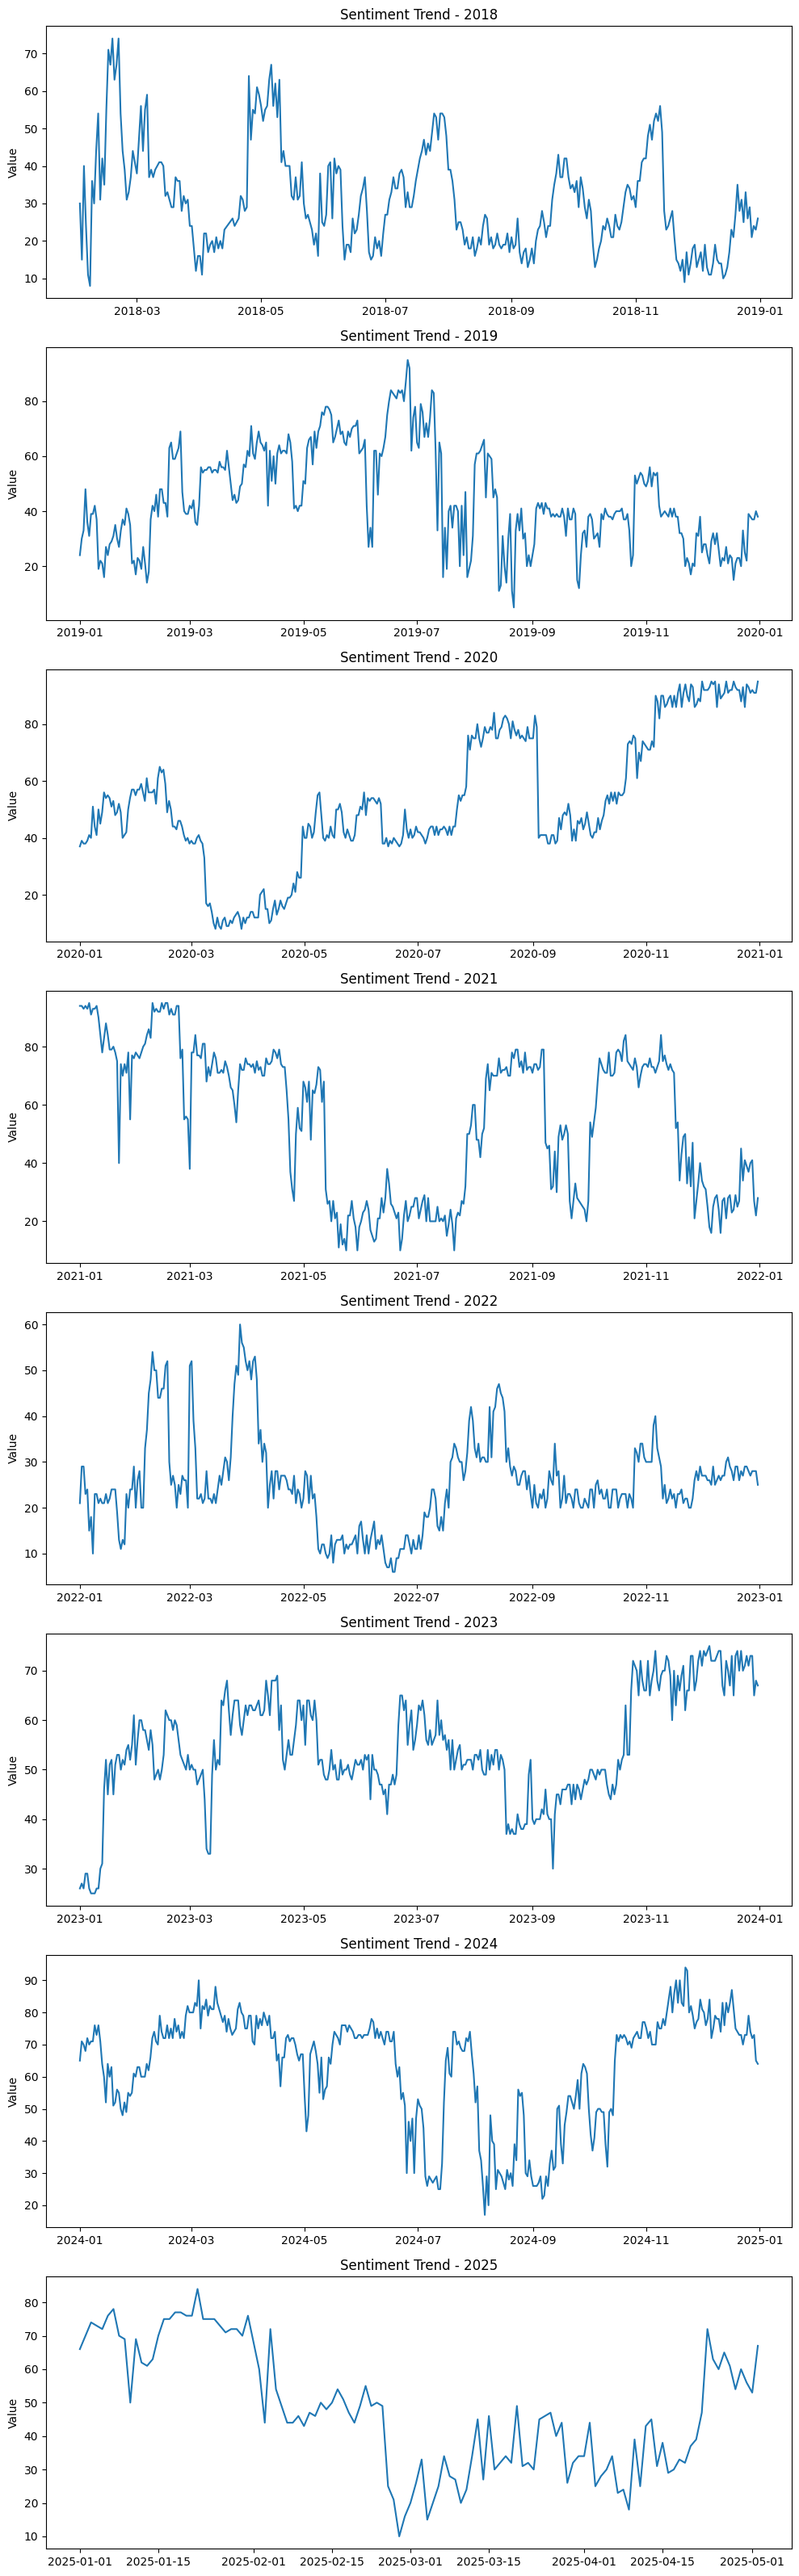

In [34]:
years = sorted(df_sentiment['year'].unique())

plt.figure(figsize=(10, 4 * len(years)))  # dynamic height

for i, year in enumerate(years, 1):
    plt.subplot(len(years), 1, i)

    data_year = df_sentiment[df_sentiment['year'] == year]

    sns.lineplot(
        data=data_year,
        x='date',
        y='value'
    )

    plt.title(f"Sentiment Trend - {year}")
    plt.xlabel("")
    plt.ylabel("Value")

plt.tight_layout()
plt.show()

### Daily Traders for Most Popular Coin

In [35]:
df_history['Timestamp IST'] = pd.to_datetime(df_history['Timestamp IST'], dayfirst=True)
df_history['year'] = df_history['Timestamp IST'].dt.year
df_history['date'] = df_history['Timestamp IST'].dt.date

In [36]:
df_buy = df_history[df_history['Side'] == 'BUY']

In [37]:
coin_popularity = df_buy.groupby(['year', 'Coin'])['Account'].nunique().reset_index()
top_coins = coin_popularity.loc[
    coin_popularity.groupby('year')['Account'].idxmax()
]

In [40]:
top_coins

,year,Coin,Account
2,2023,ETH,2
12,2024,@107,17
231,2025,HYPE,20


In [38]:
df_top = df_buy.merge(top_coins[['year','Coin']], on=['year','Coin'])

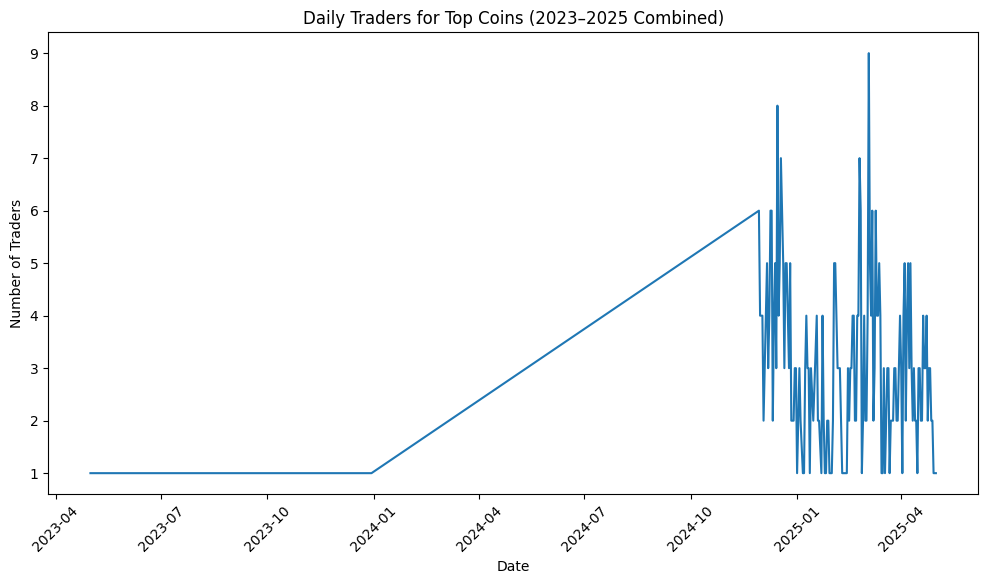

In [39]:
daily_trend = df_top.groupby(['date'])['Account'].nunique().reset_index()
daily_trend.columns = ['date', 'daily_traders']

# Step 6: Plot single line
plt.figure(figsize=(12,6))

sns.lineplot(
    data=daily_trend,
    x='date',
    y='daily_traders'
)

plt.title("Daily Traders for Top Coins (2023–2025 Combined)")
plt.xlabel("Date")
plt.ylabel("Number of Traders")

plt.xticks(rotation=45)
plt.show()

### average profit gained by traders for a particular coin

In [42]:
# Top 10 coins by total profit
top_coins = df.groupby('Coin')['Closed PnL'].sum().nlargest(10).index

df_filtered = df[df['Coin'].isin(top_coins)]

In [44]:
top_coins

Index(['@107', 'HYPE', 'SOL', 'ETH', 'BTC', 'MELANIA', 'ENA', 'SUI', 'ZRO',
       'DOGE'],
      dtype='object', name='Coin')

In [43]:
pivot_profit = df_filtered.pivot_table(
    index='Account',
    columns='Coin',
    values='Closed PnL',
    aggfunc='mean'
)

In [45]:
pivot_profit = pivot_profit.dropna(how='all')

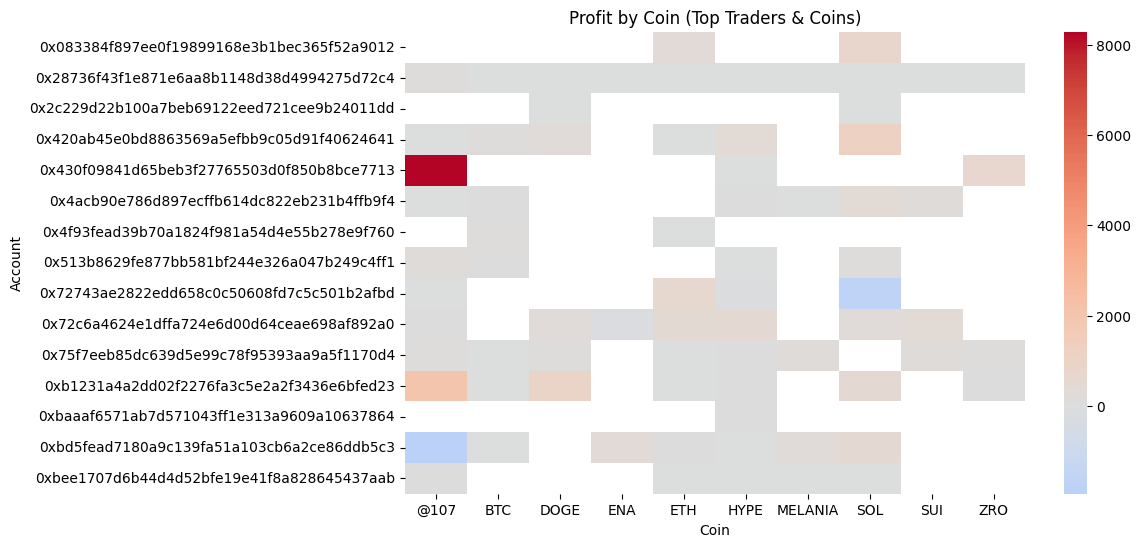

In [47]:
# Top 15 traders by total profit
top_traders = df.groupby('Account')['Closed PnL'].sum().nlargest(15).index

df_filtered = df[
    (df['Coin'].isin(top_coins)) &
    (df['Account'].isin(top_traders))
]

pivot_profit = df_filtered.pivot_table(
    index='Account',
    columns='Coin',
    values='Closed PnL',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot_profit,
    cmap='coolwarm',
    center=0,
    annot=False
)

plt.title("Profit by Coin (Top Traders & Coins)")
plt.show()

### Profit/Loss vs Sentiment

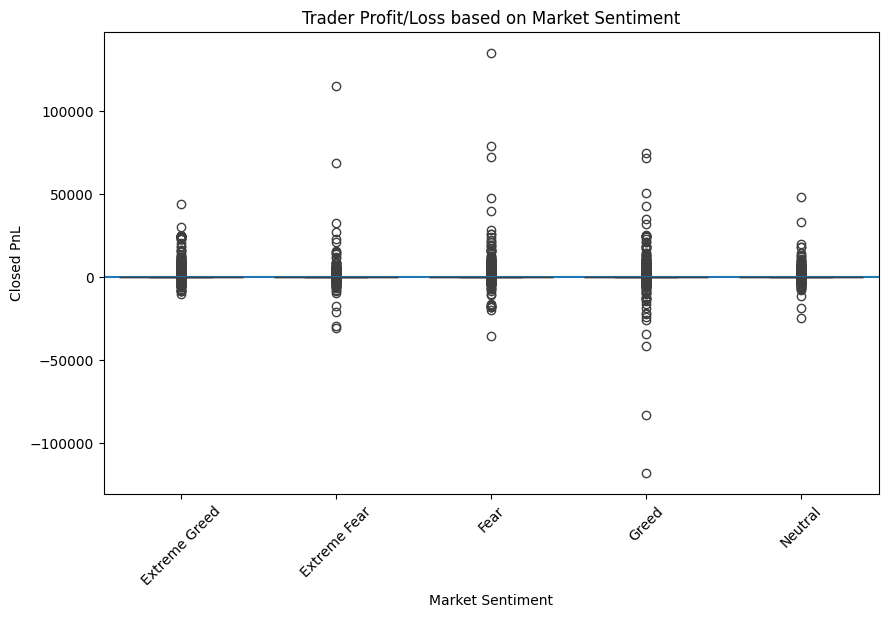

In [48]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='classification',
    y='Closed PnL'
)

plt.axhline(0)  # Profit/Loss boundary

plt.title("Trader Profit/Loss based on Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")

plt.xticks(rotation=45)
plt.show()

### Trade Count vs Sentiment

In [55]:
df['date'] = pd.to_datetime(df['Timestamp IST']).dt.floor('D')

In [56]:
daily_trades = df.groupby(['date','classification']).size().reset_index(name='trades_count')

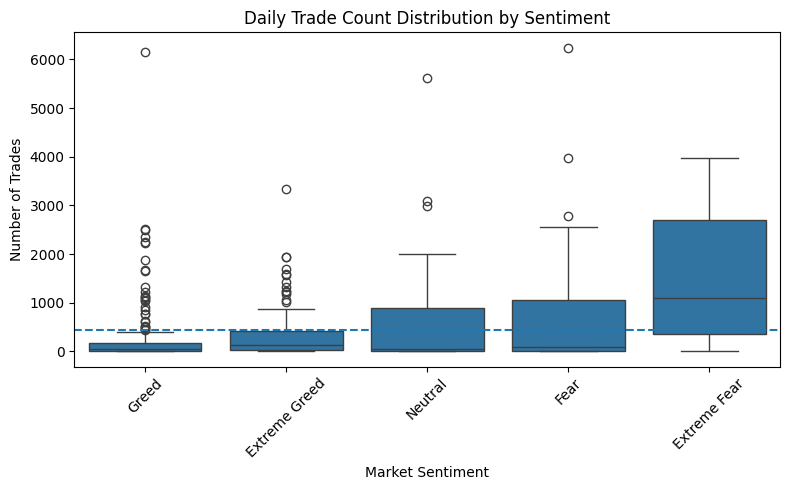

In [57]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=daily_trades,
    x='classification',
    y='trades_count'
)

plt.axhline(daily_trades['trades_count'].mean(), linestyle='--')

plt.title("Daily Trade Count Distribution by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [51]:
df['win'] = df['Closed PnL'] > 0
df.groupby('classification')['win'].mean()

,win
classification,
Extreme Fear,0.370607
Extreme Greed,0.464943
Fear,0.420768
Greed,0.384828
Neutral,0.396991


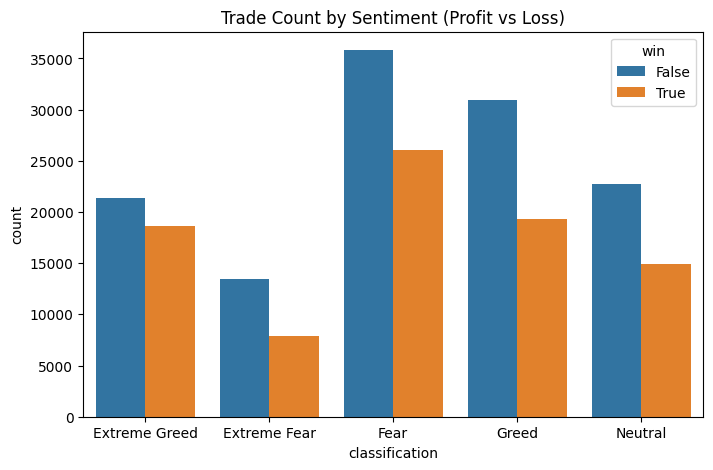

In [52]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='classification',
    hue='win'
)

plt.title("Trade Count by Sentiment (Profit vs Loss)")
plt.show()